In [1]:
#Importo Librerias. Las versiones son las explicitadas en requirements .txt.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
#Traigo datasets del github
dfproductos = pd.read_csv("https://raw.githubusercontent.com/Sebacelesia/GestionDatos/dev/data/dfproductos.csv")
dforders = pd.read_csv("https://raw.githubusercontent.com/Sebacelesia/GestionDatos/dev/data/dforders.csv")
dfclients = pd.read_csv("https://raw.githubusercontent.com/Sebacelesia/GestionDatos/dev/data/dfclientes.csv")

In [3]:
dfproductos.head()

,product_id,product_name,category,brand,last_updated,created_at
0,P00001,Lipton Ice Tea,Beverages,Unilever,2025-09-06 21:21:31,2025-04-06 21:21:31
1,P00002,Pepsi Max,Beverages,PepsiCo,2025-09-06 21:21:31,2025-05-02 21:21:31
2,P00003,Pepsi Max,Beverages,PepsiCo,2025-09-06 21:21:31,2024-10-02 21:21:31
3,P00004,Lipton Ice Tea,Beverages,Unilever,2025-09-06 21:21:31,2025-04-21 21:21:31
4,P00005,Pepsi Max,Beverages,PepsiCo,2025-09-06 21:21:31,2025-04-22 21:21:31


In [4]:
dforders.head()

,order_id,client_id,product_id,product_category,order_price,order_timestamp,order_status,payment_method,shipping_method,shipping_cost
0,1,6c5c87f2-49e9-4380-872d-71d9e3df63d6,P00333,Snacks,29.51,2023-01-01 23:51:55,delivered,bank_transfer,standard,3.51
1,2,0c8380cb-a64e-4090-8b23-d1ddf32630e0,P00929,Personal Care,23.40,2023-01-01 11:48:50,delivered,credit_card,standard,3.76
2,3,bf486527-8182-490e-9e10-c79232c6b0c9,P00768,Personal Care,94.41,2023-01-01 11:06:14,delivered,debit_card,express,10.42
3,5,6c5c87f2-49e9-4380-872d-71d9e3df63d6,P00610,Household,29.16,2023-01-01 20:55:35,delivered,credit_card,standard,6.05
4,6,7ac7a850-4f19-4c85-921b-b0e5ba921ee9,P00299,Snacks,76.22,2023-01-01 02:49:09,delivered,debit_card,express,14.08


In [5]:
dfclients.head()

,client_id,first_name,last_name,gender,age,email,city,address,postal_code,country,citizenship,document_type,document_number,registration_date,last_seen
0,21e5c13d-1c9a-4d00-9164-b72302d5edef,Tristán,Rojas,M,42,tristán.rojas13@example.com,Rivera,Bulevar Artigas 3757,28289,Uruguay,Uruguay,CI,2719583-8,2025-05-02,2025-06-19
1,36e48bdd-db11-4abe-9526-cfc90e68924d,Óscar,Barranco,M,58,óscar.barranco13@example.com,Salto,Bulevar Artigas 3911,76237,Uruguay,Uruguay,CI,1445199-8,2023-02-24,2023-12-09
2,145c22df-3579-412e-bc12-b4fce70abaf3,Macario,Querol,M,28,macario.querol67@example.com,Rivera,Av. Rivera 206,30926,Uruguay,Uruguay,CI,8090293-5,2024-10-03,2025-05-03
3,90c4a925-e51f-4dac-9193-2d9aec97a472,Ramiro,Sanchez,M,19,ramiro.sanchez53@example.com,Salto,Av. 18 de Julio 6324,22676,Uruguay,Uruguay,CI,7022674-5,2025-01-13,2025-08-11
4,853f711a-4c36-40b4-b5d0-6207152cd793,Juan Francisco,Flor,M,36,juan francisco.flor68@example.com,Mercedes,Av. 18 de Julio 6301,20328,Uruguay,Uruguay,CI,5918715-9,2025-03-09,2025-03-21


In [6]:
#Analizamos nulos, distribuciones y tipos de datos
for name, df in {'Clientes': dfclients, 'Productos': dfproductos, 'Órdenes': dforders}.items():
    print(f"\n{name}:")
    display(df.info())
    display(df.describe(include='all'))
    print(df.isnull().mean().sort_values(ascending=False).head(10))  


Clientes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   client_id          2357 non-null   object
 1   first_name         2357 non-null   object
 2   last_name          2357 non-null   object
 3   gender             2357 non-null   object
 4   age                2357 non-null   int64 
 5   email              2357 non-null   object
 6   city               2357 non-null   object
 7   address            2357 non-null   object
 8   postal_code        2357 non-null   int64 
 9   country            2357 non-null   object
 10  citizenship        2357 non-null   object
 11  document_type      2357 non-null   object
 12  document_number    2357 non-null   object
 13  registration_date  2357 non-null   object
 14  last_seen          2357 non-null   object
dtypes: int64(2), object(13)
memory usage: 276.3+ KB


None

,client_id,first_name,last_name,gender,age,email,city,address,postal_code,country,citizenship,document_type,document_number,registration_date,last_seen
count,2357,2357,2357,2357,2357.000000,2357,2357,2357,2357.000000,2357,2357,2357,2357,2357,2357
unique,2357,858,958,2,NaN,2357,9,2315,NaN,6,6,2,2357,881,691
top,21e5c13d-1c9a-4d00-9164-b72302d5edef,Ángel,Gárate,M,NaN,tristán.rojas13@example.com,Paysandú,Bulevar Artigas 7364,NaN,Uruguay,Uruguay,CI,2719583-8,2024-11-11,2025-08-25
freq,1,10,9,1215,NaN,1,287,2,NaN,2000,2000,2000,1,10,20
mean,NaN,NaN,NaN,NaN,34.921935,NaN,NaN,NaN,54607.319050,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,13.057754,NaN,NaN,NaN,25677.765405,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,10064.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN,31990.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,34.000000,NaN,NaN,NaN,54553.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,44.000000,NaN,NaN,NaN,76527.000000,NaN,NaN,NaN,NaN,NaN,NaN


client_id      0.0
first_name     0.0
last_name      0.0
gender         0.0
age            0.0
email          0.0
city           0.0
address        0.0
postal_code    0.0
country        0.0
dtype: float64

Productos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    1255 non-null   object
 1   product_name  1255 non-null   object
 2   category      1255 non-null   object
 3   brand         1255 non-null   object
 4   last_updated  1255 non-null   object
 5   created_at    1255 non-null   object
dtypes: object(6)
memory usage: 59.0+ KB


None

,product_id,product_name,category,brand,last_updated,created_at
count,1255,1255,1255,1255,1255,1255
unique,1255,24,5,20,1,322
top,P00001,Domestos Bleach,Beverages,Unilever,2025-09-06 21:21:31,2024-09-14 21:21:31
freq,1,67,251,176,1255,10


product_id      0.0
product_name    0.0
category        0.0
brand           0.0
last_updated    0.0
created_at      0.0
dtype: float64

Órdenes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82245 entries, 0 to 82244
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          82245 non-null  int64  
 1   client_id         82245 non-null  object 
 2   product_id        82245 non-null  object 
 3   product_category  82245 non-null  object 
 4   order_price       82245 non-null  float64
 5   order_timestamp   82245 non-null  object 
 6   order_status      82245 non-null  object 
 7   payment_method    82245 non-null  object 
 8   shipping_method   82245 non-null  object 
 9   shipping_cost     82245 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 6.3+ MB


None

,order_id,client_id,product_id,product_category,order_price,order_timestamp,order_status,payment_method,shipping_method,shipping_cost
count,82245.000000,82245,82245,82245,82245.000000,82245,82245,82245,82245,82245.000000
unique,NaN,2255,1255,5,NaN,82181,2,5,3,NaN
top,NaN,478705d6-7a06-470a-a116-8b177a34d8d0,P01173,Technology,NaN,2023-01-19 03:13:08,delivered,credit_card,standard,NaN
freq,NaN,179,114,22923,NaN,2,81803,32987,57356,NaN
mean,44094.374357,NaN,NaN,NaN,52.822550,NaN,NaN,NaN,NaN,5.513564
std,26109.602653,NaN,NaN,NaN,28.695925,NaN,NaN,NaN,NaN,2.970726
min,1.000000,NaN,NaN,NaN,0.860000,NaN,NaN,NaN,NaN,0.000000
25%,21382.000000,NaN,NaN,NaN,28.800000,NaN,NaN,NaN,NaN,4.210000
50%,43478.000000,NaN,NaN,NaN,54.170000,NaN,NaN,NaN,NaN,5.180000
75%,66465.000000,NaN,NaN,NaN,77.190000,NaN,NaN,NaN,NaN,6.410000


order_id            0.0
client_id           0.0
product_id          0.0
product_category    0.0
order_price         0.0
order_timestamp     0.0
order_status        0.0
payment_method      0.0
shipping_method     0.0
shipping_cost       0.0
dtype: float64


=== Perfil básico de Clientes ===

Forma del dataset: (2357, 15)

Tipos de datos:
client_id            object
first_name           object
last_name            object
gender               object
age                   int64
email                object
city                 object
address              object
postal_code           int64
country              object
citizenship          object
document_type        object
document_number      object
registration_date    object
last_seen            object
dtype: object

Valores faltantes (%):
client_id            0.0
first_name           0.0
last_name            0.0
gender               0.0
age                  0.0
email                0.0
city                 0.0
address              0.0
postal_code          0.0
country              0.0
citizenship          0.0
document_type        0.0
document_number      0.0
registration_date    0.0
last_seen            0.0
dtype: float64

Estadísticas numéricas:
              count          mean           s

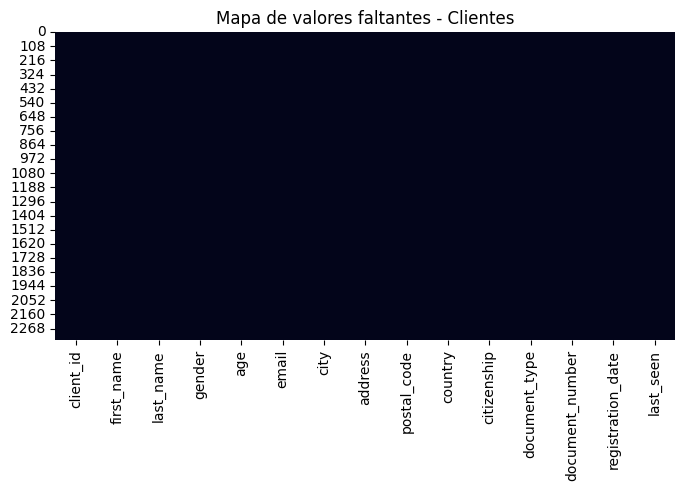

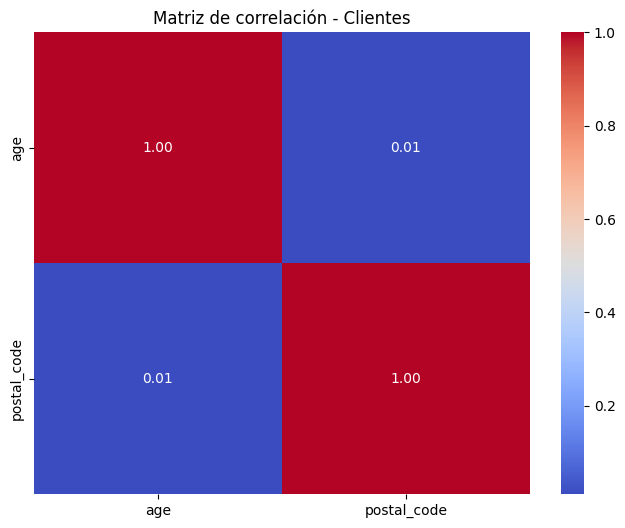

=== Perfil básico de Productos ===

Forma del dataset: (1255, 6)

Tipos de datos:
product_id      object
product_name    object
category        object
brand           object
last_updated    object
created_at      object
dtype: object

Valores faltantes (%):
product_id      0.0
product_name    0.0
category        0.0
brand           0.0
last_updated    0.0
created_at      0.0
dtype: float64

Estadísticas numéricas:
             count unique                  top  freq
product_id    1255   1255               P00001     1
product_name  1255     24      Domestos Bleach    67
category      1255      5            Beverages   251
brand         1255     20             Unilever   176
last_updated  1255      1  2025-09-06 21:21:31  1255
created_at    1255    322  2024-09-14 21:21:31    10

Estadísticas categóricas:

product_id (top 5 categorías):
product_id
P00001    1
P00835    1
P00842    1
P00841    1
P00840    1
Name: count, dtype: int64

product_name (top 5 categorías):
product_name
Domestos

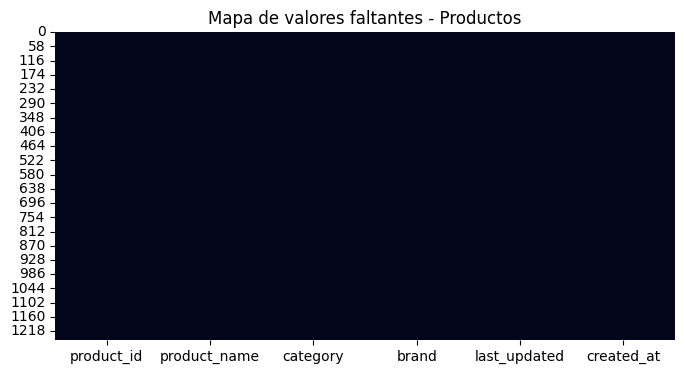

=== Perfil básico de Orders ===

Forma del dataset: (82245, 10)

Tipos de datos:
order_id              int64
client_id            object
product_id           object
product_category     object
order_price         float64
order_timestamp      object
order_status         object
payment_method       object
shipping_method      object
shipping_cost       float64
dtype: object

Valores faltantes (%):
order_id            0.0
client_id           0.0
product_id          0.0
product_category    0.0
order_price         0.0
order_timestamp     0.0
order_status        0.0
payment_method      0.0
shipping_method     0.0
shipping_cost       0.0
dtype: float64

Estadísticas numéricas:
                 count          mean           std   min       25%       50%  \
order_id       82245.0  44094.374357  26109.602653  1.00  21382.00  43478.00   
order_price    82245.0     52.822550     28.695925  0.86     28.80     54.17   
shipping_cost  82245.0      5.513564      2.970726  0.00      4.21      5.18   



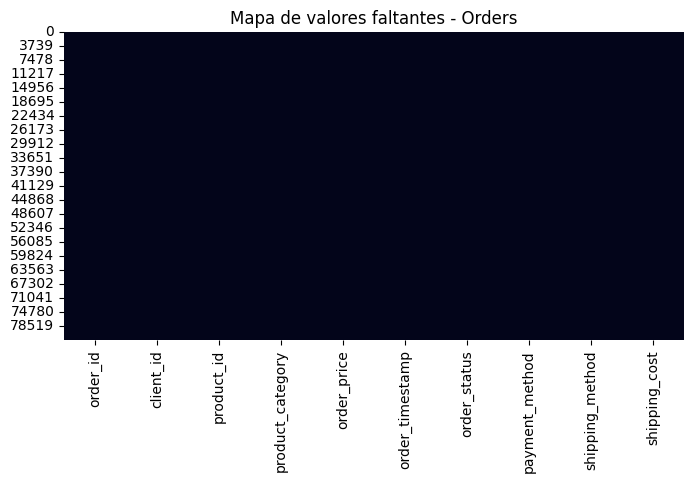

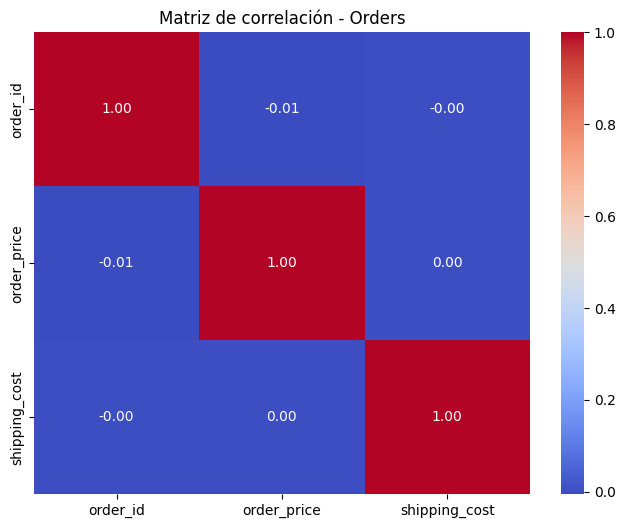

In [7]:
def perfil_basico(df, nombre="Dataset"):
    print(f"=== Perfil básico de {nombre} ===\n")
    
    print("Forma del dataset:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
    
    print("\nValores faltantes (%):")
    print((df.isnull().mean() * 100).round(2))
    
    print("\nEstadísticas numéricas:")
    print(df.describe().T)
    
    print("\nEstadísticas categóricas:")
    cat_cols = df.select_dtypes(include='object').columns
    for col in cat_cols:
        print(f"\n{col} (top 5 categorías):")
        print(df[col].value_counts().head(5))
    
    plt.figure(figsize=(8, 4))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title(f"Mapa de valores faltantes - {nombre}")
    plt.show()
    
    num_cols = df.select_dtypes(include='number').columns
    if len(num_cols) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
        plt.title(f"Matriz de correlación - {nombre}")
        plt.show()
perfil_basico(dfclients, "Clientes")
perfil_basico(dfproductos, "Productos")
perfil_basico(dforders, "Orders")

Se observa como no tenemos valores faltantes en el dataset. A su vez la mayoria de los tipos de datos parecen estar bien, salvo las fechas que debemos pasarlas a formato date. 

También observamos como la gran mayoria de compras se generan en Uruguay, y los productos mas vendidos son los de tecnologia, aunque hay un gran numero de compras de comestibles también.

C:\Users\59892\AppData\Local\Temp\ipykernel_33776\2151064525.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='product_name', x='order_id', data=top_products, palette='Purples_r', ax=axes[1,1])


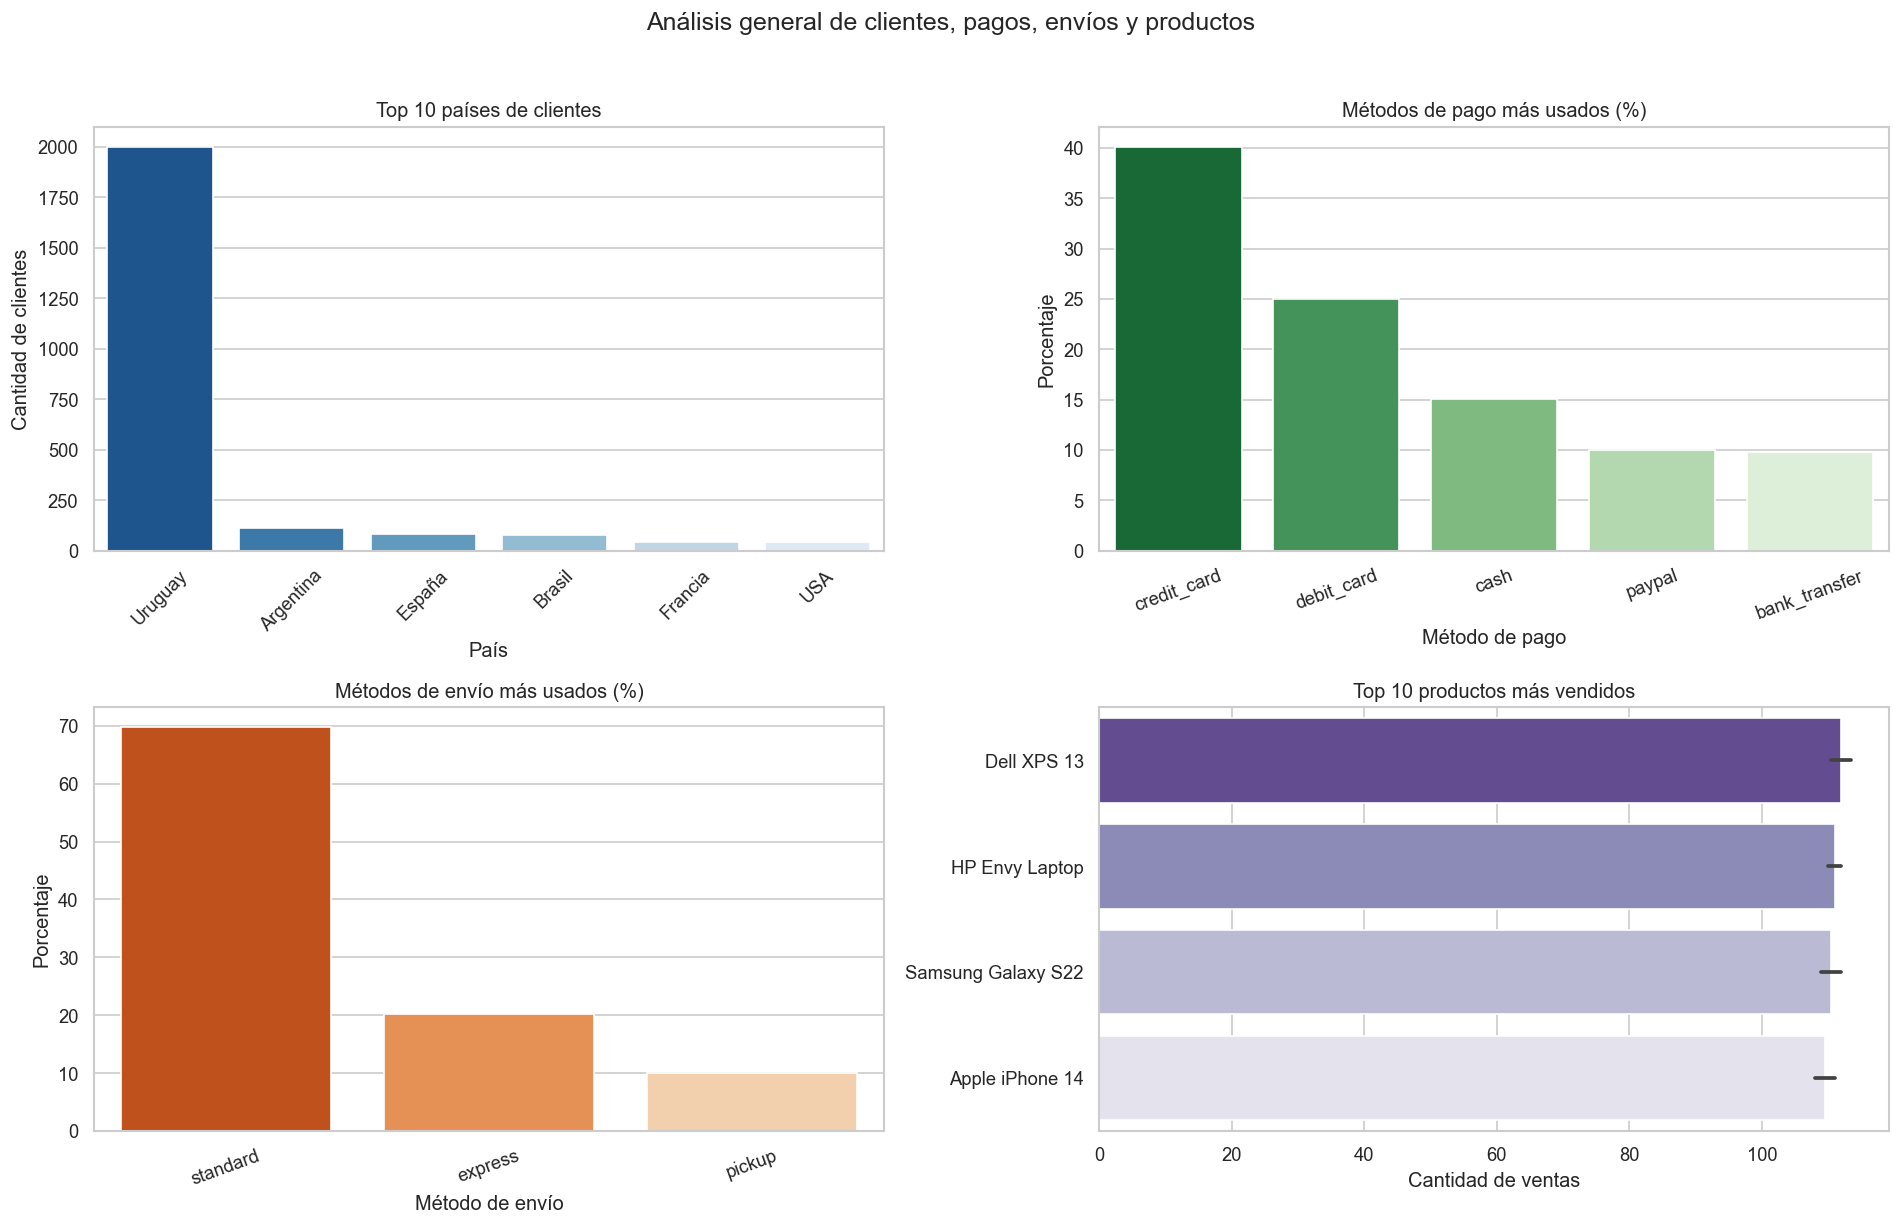

In [31]:
sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 120  # mejor calidad

top_paises = dfclients['country'].value_counts().head(10)

payment_counts = dforders['payment_method'].value_counts(normalize=True) * 100
shipping_counts = dforders['shipping_method'].value_counts(normalize=True) * 100

top_products = (
    dforders.groupby('product_id')['order_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .merge(dfproductos[['product_id', 'product_name']], on='product_id', how='left')
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))  # más grande

sns.barplot(x=top_paises.index, y=top_paises.values, hue=top_paises.index, legend=False, palette='Blues_r', ax=axes[0,0])
axes[0,0].set_title('Top 10 países de clientes')
axes[0,0].set_ylabel('Cantidad de clientes')
axes[0,0].set_xlabel('País')
axes[0,0].tick_params(axis='x', rotation=45)

sns.barplot(x=payment_counts.index, y=payment_counts.values, hue=payment_counts.index, legend=False, palette='Greens_r', ax=axes[0,1])
axes[0,1].set_title('Métodos de pago más usados (%)')
axes[0,1].set_ylabel('Porcentaje')
axes[0,1].set_xlabel('Método de pago')
axes[0,1].tick_params(axis='x', rotation=20)

sns.barplot(x=shipping_counts.index, y=shipping_counts.values, hue=shipping_counts.index, legend=False, palette='Oranges_r', ax=axes[1,0])
axes[1,0].set_title('Métodos de envío más usados (%)')
axes[1,0].set_ylabel('Porcentaje')
axes[1,0].set_xlabel('Método de envío')
axes[1,0].tick_params(axis='x', rotation=20)

sns.barplot(y='product_name', x='order_id', data=top_products, palette='Purples_r', ax=axes[1,1])
axes[1,1].set_title('Top 10 productos más vendidos')
axes[1,1].set_xlabel('Cantidad de ventas')
axes[1,1].set_ylabel('')

plt.suptitle('Análisis general de clientes, pagos, envíos y productos', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

Se observa como la mayoria de clientes son de Uruguay. Las compras con tarjetas, particularmente las de tarjeta de crédito, son las que tienen mayor cantidad de compras. El metodo de envio mas usado es el standard, aunque tambien hay envios express o de pickup. Los productos mas vendidos son de tecnologia.

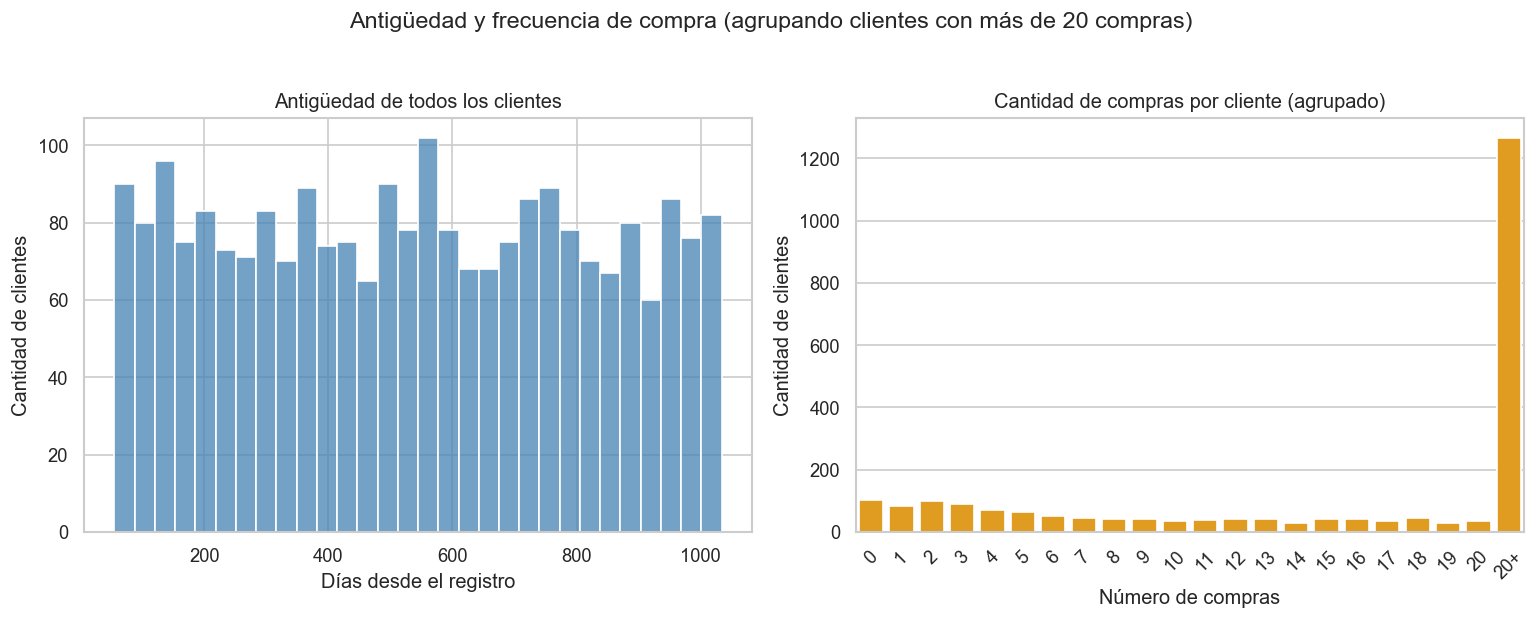

In [41]:
# --- Calcular antigüedad ---
dfclients['registration_date'] = pd.to_datetime(dfclients['registration_date'])
dfclients['antiguedad_dias'] = (pd.Timestamp.now() - dfclients['registration_date']).dt.days

# --- Calcular cantidad de compras por cliente ---
compras_por_cliente = dforders.groupby('client_id')['order_id'].count().reset_index()
compras_por_cliente.columns = ['client_id', 'n_compras']

# Merge con dfclients
df_antiguedad = dfclients.merge(compras_por_cliente, on='client_id', how='left')
df_antiguedad['n_compras'] = df_antiguedad['n_compras'].fillna(0).astype(int)

df_antiguedad['n_compras_grupo'] = np.where(df_antiguedad['n_compras'] > 20, 21, df_antiguedad['n_compras'])
labels = [str(i) for i in range(0, 21)] + ['20+']
df_antiguedad['n_compras_label'] = df_antiguedad['n_compras_grupo'].replace({21: '20+'}).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.histplot(df_antiguedad['antiguedad_dias'], bins=30, color='steelblue', ax=axes[0])
axes[0].set_title('Antigüedad de todos los clientes')
axes[0].set_xlabel('Días desde el registro')
axes[0].set_ylabel('Cantidad de clientes')

sns.countplot(x='n_compras_label', data=df_antiguedad, color='orange', ax=axes[1],
              order=[str(i) for i in range(0, 21)] + ['20+'])
axes[1].set_title('Cantidad de compras por cliente (agrupado)')
axes[1].set_xlabel('Número de compras')
axes[1].set_ylabel('Cantidad de clientes')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Antigüedad y frecuencia de compra (agrupando clientes con más de 20 compras)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()



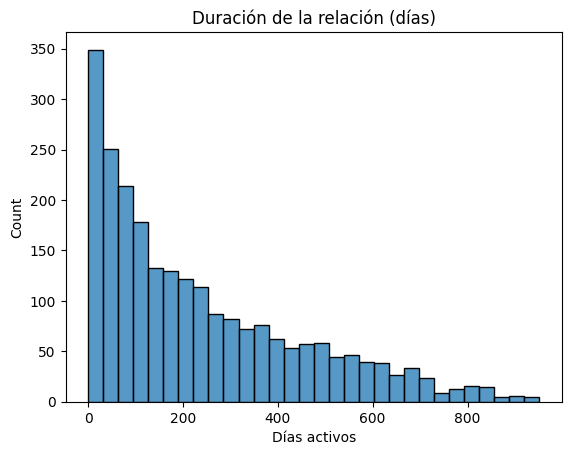

In [12]:
dfclients['registration_date'] = pd.to_datetime(dfclients['registration_date'])
dfclients['last_seen'] = pd.to_datetime(dfclients['last_seen'])
dfclients['duracion_dias'] = (dfclients['last_seen'] - dfclients['registration_date']).dt.days

sns.histplot(dfclients['duracion_dias'], bins=30)
plt.title('Duración de la relación (días)')
plt.xlabel('Días activos')
plt.show()


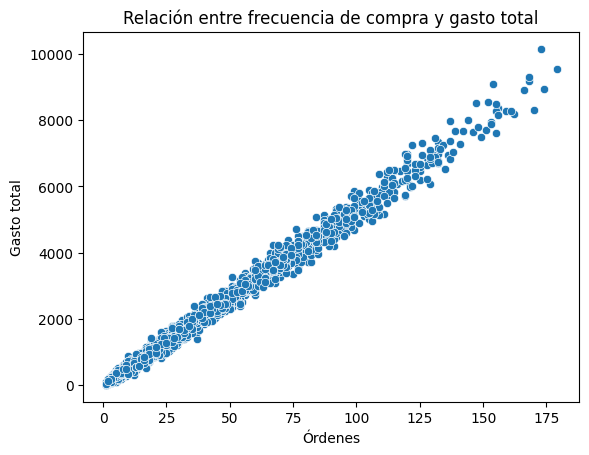

In [13]:
ventas_por_cliente = dforders.groupby('client_id')['order_price'].sum().reset_index()
ordenes_por_cliente = dforders.groupby('client_id')['order_id'].count().reset_index()
ordenes_por_cliente.columns = ['client_id', 'n_ordenes']

cliente_stats = ventas_por_cliente.merge(ordenes_por_cliente, on='client_id')
sns.scatterplot(x='n_ordenes', y='order_price', data=cliente_stats)
plt.title('Relación entre frecuencia de compra y gasto total')
plt.xlabel('Órdenes')
plt.ylabel('Gasto total')
plt.show()


Se observa que a mayor cantidad de ordenes el gasto total del cliente es mayor.

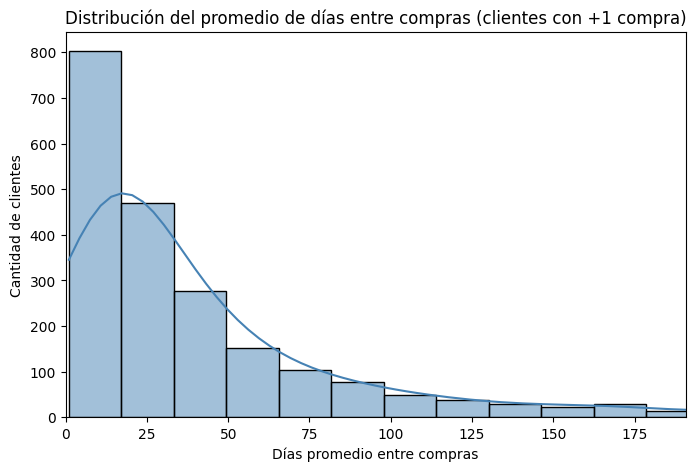

In [16]:
# Aseguramos formato datetime
dforders['order_timestamp'] = pd.to_datetime(dforders['order_timestamp'])

# Filtrar clientes con más de una compra
multi_buyers = dforders.groupby('client_id').filter(lambda x: len(x) > 1)

# Calcular diferencia entre compras por cliente
multi_buyers = multi_buyers.sort_values(['client_id', 'order_timestamp'])
multi_buyers['diff_days'] = multi_buyers.groupby('client_id')['order_timestamp'].diff().dt.days

# Promedio de días entre compras por cliente
avg_diff = (
    multi_buyers.groupby('client_id')['diff_days']
    .mean()
    .dropna()
    .reset_index()
)

avg_diff.rename(columns={'diff_days': 'promedio_dias_entre_compras'}, inplace=True)
avg_diff.head()
plt.figure(figsize=(8,5))
sns.histplot(avg_diff['promedio_dias_entre_compras'], bins=40, kde=True, color='steelblue')
plt.title('Distribución del promedio de días entre compras (clientes con +1 compra)')
plt.xlabel('Días promedio entre compras')
plt.ylabel('Cantidad de clientes')
plt.xlim(0, avg_diff['promedio_dias_entre_compras'].quantile(0.95))  # quitar outliers visuales
plt.show()

Para medir el target este grafico nos parece muy importante. Se observa que la moda de dias promedio entre compras claramente está a los 20 dias. Sin embargo, existen clientes que demoran hasta 180 dias para realizar una compra consecutiva. 
En el grafico de a continuación observamos si esta relacionado con el rubro de compra.

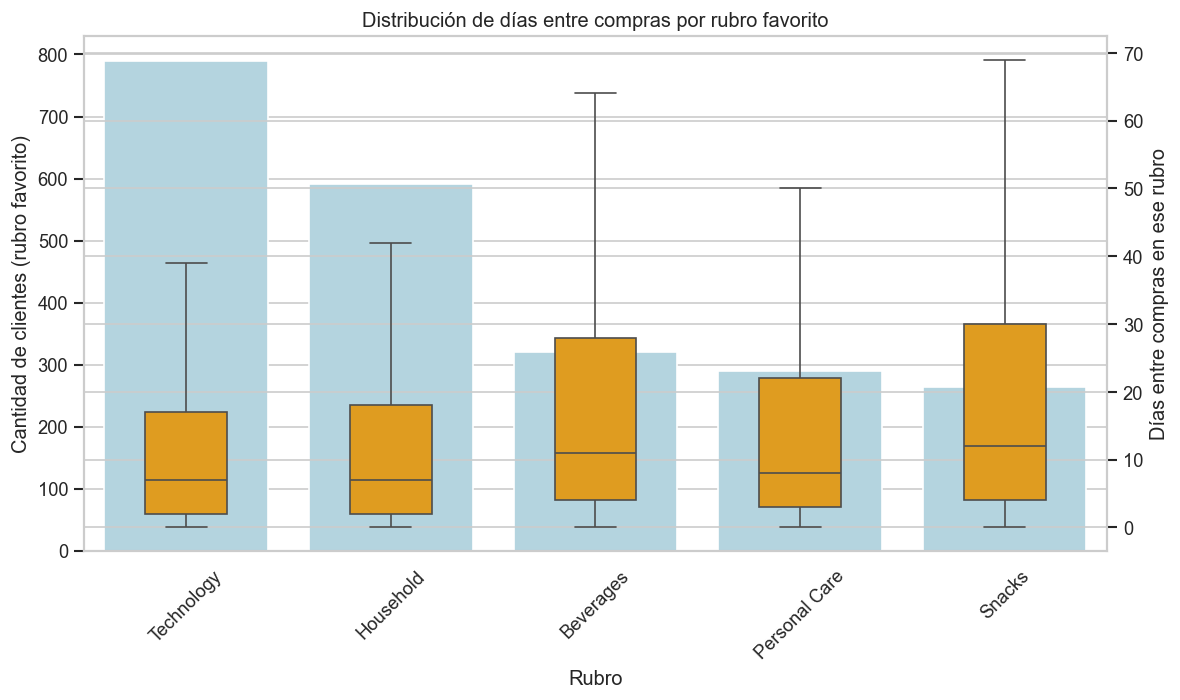

In [36]:
# Aseguramos que diff_dias está calculado
dforders['order_timestamp'] = pd.to_datetime(dforders['order_timestamp'])
df_sorted = dforders.sort_values(['client_id', 'order_timestamp'])
df_sorted['diff_dias'] = df_sorted.groupby('client_id')['order_timestamp'].diff().dt.days

# Nos quedamos con registros válidos
df_valid = df_sorted.dropna(subset=['diff_dias'])

# Moda del rubro por cliente
rubro_moda = (
    dforders.groupby('client_id')['product_category']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'product_category': 'rubro_favorito'})
)

# Unimos para saber el rubro principal de cada cliente
df_valid = df_valid.merge(rubro_moda, on='client_id', how='left')

# Filtramos solo compras dentro del rubro favorito
df_valid = df_valid[df_valid['product_category'] == df_valid['rubro_favorito']]

# --- Gráfico combinado ---
fig, ax1 = plt.subplots(figsize=(10,6))

# Barras: cantidad de clientes con ese rubro favorito
clientes_por_rubro = rubro_moda['rubro_favorito'].value_counts().reset_index()
clientes_por_rubro.columns = ['rubro_favorito', 'n_clientes']

sns.barplot(x='rubro_favorito', y='n_clientes', data=clientes_por_rubro, color='lightblue', ax=ax1)
ax1.set_ylabel('Cantidad de clientes (rubro favorito)')
ax1.set_xlabel('Rubro')
ax1.tick_params(axis='x', rotation=45)

# Segundo eje para boxplot (superpuesto)
ax2 = ax1.twinx()
sns.boxplot(x='rubro_favorito', y='diff_dias', data=df_valid, ax=ax2, color='orange', width=0.4, showfliers=False)
ax2.set_ylabel('Días entre compras en ese rubro')

plt.title('Distribución de días entre compras por rubro favorito')
plt.tight_layout()
plt.show()


C:\Users\59892\AppData\Local\Temp\ipykernel_33776\916512703.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='n_clientes', data=clientes_ciudad.head(10), ax=axes[0], palette='Blues_r')
C:\Users\59892\AppData\Local\Temp\ipykernel_33776\916512703.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city', y='shipping_cost', data=df_top_cities, ax=axes[1], palette='Oranges')


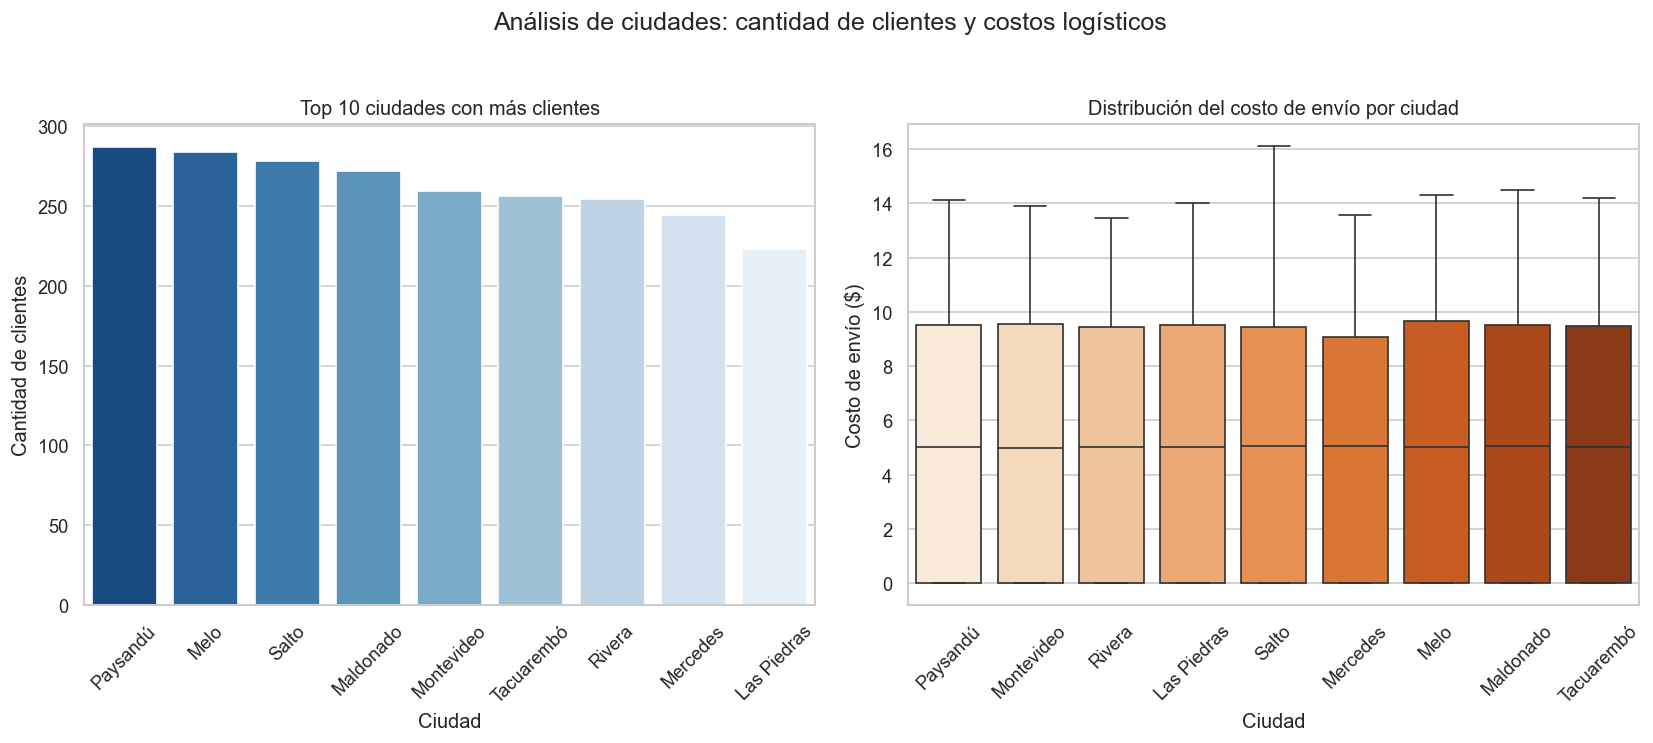

In [46]:
# --- Calcular cantidad de clientes por ciudad ---
clientes_ciudad = dfclients['city'].value_counts().reset_index()
clientes_ciudad.columns = ['city', 'n_clientes']

# --- Calcular promedio de costo de envío por cliente ---
prom_shipping = (
    dforders.groupby(['client_id', 'shipping_method'])['shipping_cost']
    .mean()
    .reset_index()
    .merge(dfclients[['client_id', 'city']], on='client_id', how='left')
)

# --- Promedio general de shipping cost por ciudad ---
shipping_ciudad = (
    prom_shipping.groupby('city')['shipping_cost']
    .mean()
    .reset_index()
)

# --- Top 10 ciudades con más clientes ---
top_cities = clientes_ciudad.head(10)['city']
df_top_cities = prom_shipping[prom_shipping['city'].isin(top_cities)]
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(x='city', y='n_clientes', data=clientes_ciudad.head(10), ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 ciudades con más clientes')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='city', y='shipping_cost', data=df_top_cities, ax=axes[1], palette='Oranges')
axes[1].set_title('Distribución del costo de envío por ciudad')
axes[1].set_xlabel('Ciudad')
axes[1].set_ylabel('Costo de envío ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis de ciudades: cantidad de clientes y costos logísticos', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

Se observa como hay una gran variabilidad entre las ciudades de los clientes. Sin embargo, esto no hace discriminar el costo de envio en los pedidos por ciudad.

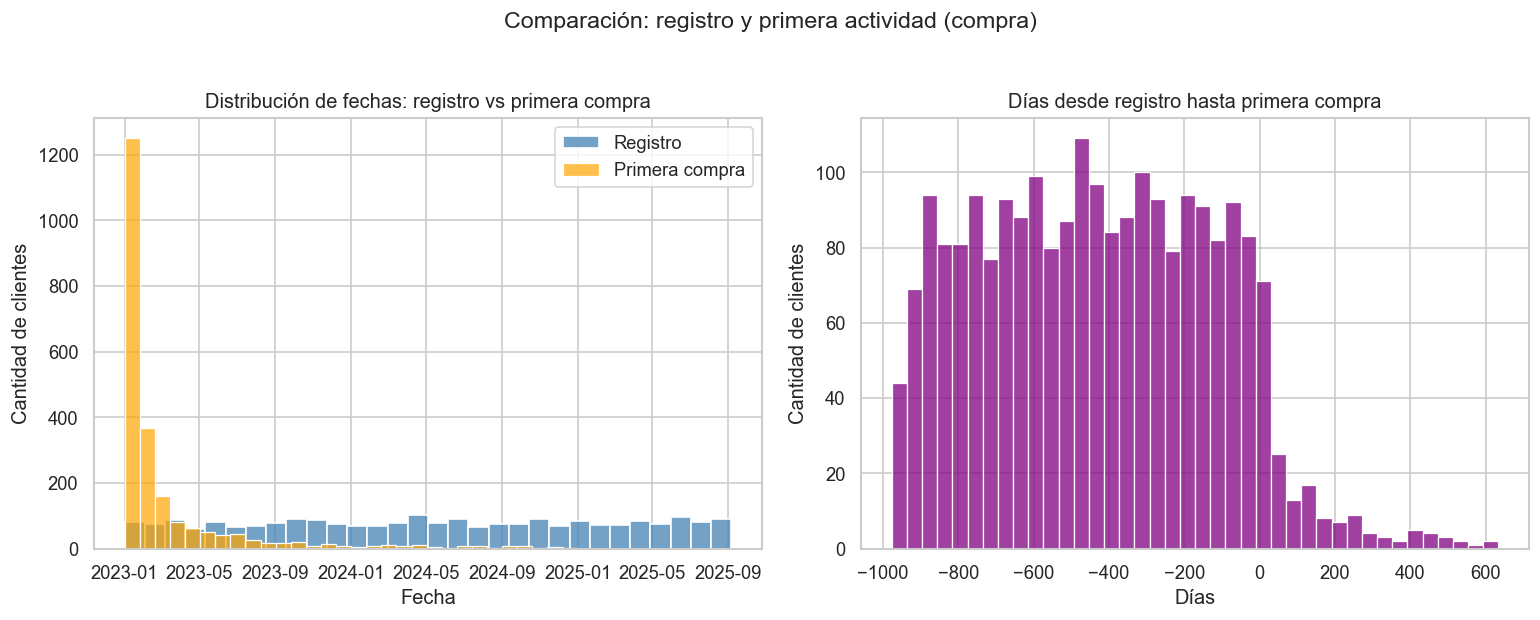

In [45]:
dfclients['registration_date'] = pd.to_datetime(dfclients['registration_date'])
dforders['order_timestamp'] = pd.to_datetime(dforders['order_timestamp'])

primera_compra = (
    dforders.groupby('client_id')['order_timestamp']
    .min()
    .reset_index()
    .rename(columns={'order_timestamp': 'first_purchase_date'})
)

df_registro = dfclients.merge(primera_compra, on='client_id', how='left')

df_registro['dias_hasta_primera_compra'] = (
    df_registro['first_purchase_date'] - df_registro['registration_date']
).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.histplot(df_registro['registration_date'], bins=30, color='steelblue', ax=axes[0], label='Registro')
sns.histplot(df_registro['first_purchase_date'], bins=30, color='orange', ax=axes[0], label='Primera compra', alpha=0.7)
axes[0].set_title('Distribución de fechas: registro vs primera compra')
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Cantidad de clientes')
axes[0].legend()

sns.histplot(df_registro['dias_hasta_primera_compra'].dropna(), bins=40, color='purple', ax=axes[1])
axes[1].set_title('Días desde registro hasta primera compra')
axes[1].set_xlabel('Días')
axes[1].set_ylabel('Cantidad de clientes')

plt.suptitle('Comparación: registro y primera actividad (compra)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()


Estos graficos nos hacen dudar del significado de registration_date. Al parecer los clientes podían hacer compras previas, por lo que nos hace dudar de la importancia del dato.